# 01 — Exploratory Data Analysis

Catalog-level overview of the **South Asia earthquake catalog** built by
`src.fetch_usgs` (USGS FDSNWS, 1973–present, M ≥ 3.5, lat 23–38°, lon 60–78°).

This notebook answers four questions before any feature engineering:

1. **Scope** — how big is the catalog and what columns are in it?
2. **Magnitude completeness** — above what magnitude is the catalog reliable?
3. **Geography & depth** — where do these earthquakes happen, and how deep?
4. **Time** — how does the catalog evolve, and is detection improving?

It also flags **data-quality** issues (missing fields, encoding artefacts) that
the report should disclose.

See [PROJECT_PROPOSAL.md](../PROJECT_PROPOSAL.md) section 7 (Phase B).

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sns.set_theme(context="notebook", style="whitegrid")
print("OK")

OK


### Helper functions

Two small functions used in section 2 (magnitude completeness): one estimates
the **magnitude of completeness** Mc by the textbook max-curvature method,
the other fits the **Gutenberg–Richter law** above Mc.

In [2]:
def estimate_completeness_magnitude(magnitudes, bin_width=0.1):
    """Mc ≈ the magnitude bin with the most events (max-curvature method)."""
    bins = np.arange(magnitudes.min() - bin_width, magnitudes.max() + bin_width, bin_width)
    counts, edges = np.histogram(magnitudes, bins=bins)
    bin_centers = 0.5 * (edges[:-1] + edges[1:])
    return float(bin_centers[int(np.argmax(counts))])


def fit_gutenberg_richter(magnitudes, mc, step=0.1, min_count=10):
    """Fit log10 N(>=M) = a - b * M to magnitudes >= Mc.

    Returns: b_value, intercept, magnitude_grid, n_at_or_above.
    """
    magnitude_grid = np.arange(mc, magnitudes.max() + step, step)
    n_at_or_above = np.array(
        [(magnitudes >= m).sum() for m in magnitude_grid], dtype=float
    )
    enough_data = n_at_or_above >= min_count
    slope, intercept = np.polyfit(
        magnitude_grid[enough_data],
        np.log10(n_at_or_above[enough_data]),
        deg=1,
    )
    return -slope, intercept, magnitude_grid, n_at_or_above

## 1. Scope — load the catalog and inspect its shape

In [3]:
catalog = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "catalog.parquet")
print(f"Rows:    {len(catalog):,}")
print(f"Columns: {catalog.shape[1]}")

Rows:    12,866
Columns: 15


In [4]:
first_event = catalog["time"].min()
last_event = catalog["time"].max()
print(f"Period:  {first_event.date()}  →  {last_event.date()}  "
      f"({(last_event - first_event).days / 365.25:.1f} years)")
print(f"Region:  lat {catalog['latitude'].min():.2f}°–{catalog['latitude'].max():.2f}°,  "
      f"lon {catalog['longitude'].min():.2f}°–{catalog['longitude'].max():.2f}°")
print(f"Mag:     {catalog['mag'].min():.1f}  →  {catalog['mag'].max():.1f}")

Period:  1973-01-02  →  2026-05-06  (53.3 years)
Region:  lat 23.02°–38.00°,  lon 60.00°–78.00°
Mag:     3.5  →  7.7


Schema:

In [5]:
print(catalog.dtypes.to_string())

id                           str
time         datetime64[ms, UTC]
longitude                float64
latitude                 float64
depth                    float64
mag                      float64
magType                      str
place                        str
type                         str
status                       str
net                          str
rms                      float64
gap                      float64
dmin                     float64
nst                      float64


First five rows:

In [6]:
catalog.head()

,id,time,longitude,latitude,depth,mag,magType,place,type,status,net,rms,gap,dmin,nst
0,usp000000g,1973-01-02 16:25:36+00:00,71.308,36.085,137.0,4.8,mb,"69 km SSW of Ashk?sham, Afghanistan",earthquake,reviewed,us,NaN,NaN,NaN,NaN
1,usp0000038,1973-01-10 03:02:32.100000+00:00,68.332,32.641,18.0,4.8,mb,central Afghanistan,earthquake,reviewed,us,NaN,NaN,NaN,NaN
2,usp000003p,1973-01-10 21:07:45.600000+00:00,70.974,36.225,110.0,4.3,mb,"71 km SW of Ashk?sham, Afghanistan",earthquake,reviewed,us,NaN,NaN,NaN,NaN
3,usp0000049,1973-01-12 23:39:25.900000+00:00,70.581,35.992,126.0,5.2,mb,"70 km NNW of P?r?n, Afghanistan",earthquake,reviewed,us,NaN,NaN,NaN,NaN
4,usp000004k,1973-01-13 14:14:41.100000+00:00,63.895,25.581,50.0,5.0,mb,"55 km NE of Pasni, Pakistan",earthquake,reviewed,us,NaN,NaN,NaN,NaN


## 2. Magnitude distribution and completeness

The catalog is only **complete** above some threshold magnitude **Mc**: small
earthquakes get missed because regional networks cannot detect them. Below Mc
the histogram dips; above Mc it follows Gutenberg–Richter exponential decay.

We estimate Mc with the **maximum-curvature method** (the magnitude bin with
the most events) and then fit the GR slope on `M ≥ Mc`.

### 2.1 Estimate Mc

In [7]:
mc = estimate_completeness_magnitude(catalog["mag"])
print(f"Magnitude of completeness  Mc ≈ {mc:.1f}")

Magnitude of completeness  Mc ≈ 4.1


### 2.2 Magnitude histogram

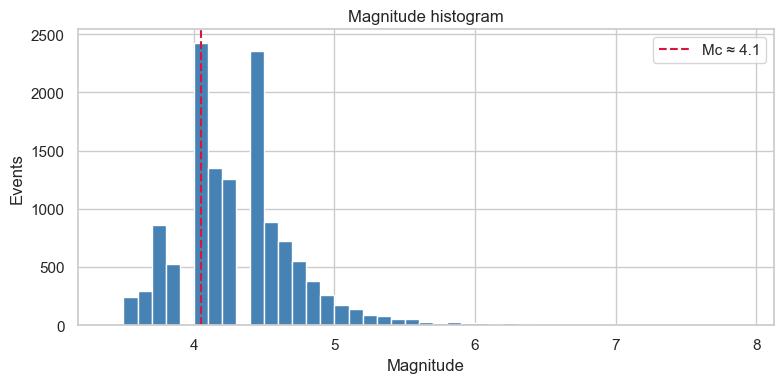

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(catalog["mag"], bins=np.arange(3.4, 8.0, 0.1), color="steelblue", edgecolor="white")
ax.axvline(mc, color="crimson", ls="--", label=f"Mc ≈ {mc:.1f}")
ax.set(xlabel="Magnitude", ylabel="Events", title="Magnitude histogram")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "01_magnitude_histogram.png", dpi=120, bbox_inches="tight")
plt.show()

### 2.3 Gutenberg–Richter fit

In [9]:
b_value, intercept, mag_grid, n_ge_m = fit_gutenberg_richter(catalog["mag"], mc)
print(f"b-value (slope of GR fit above Mc) = {b_value:.2f}    (textbook ≈ 1.0)")

b-value (slope of GR fit above Mc) = 1.05    (textbook ≈ 1.0)


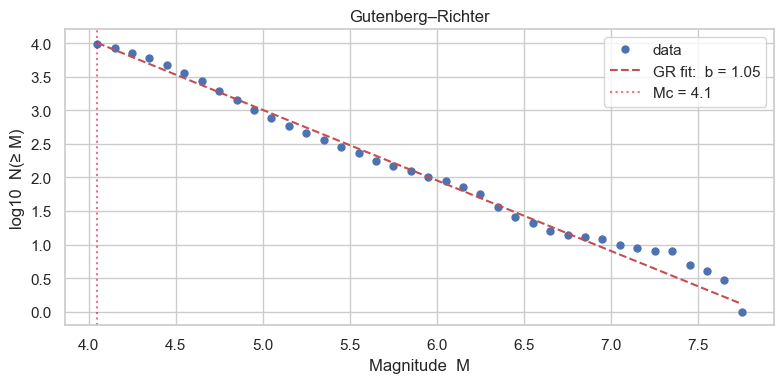

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mag_grid, np.log10(np.maximum(n_ge_m, 1)), "o", ms=5, label="data")
ax.plot(mag_grid, -b_value * mag_grid + intercept, "r--",
        label=f"GR fit:  b = {b_value:.2f}")
ax.axvline(mc, color="crimson", ls=":", alpha=0.6, label=f"Mc = {mc:.1f}")
ax.set(xlabel="Magnitude  M", ylabel="log10  N(≥ M)", title="Gutenberg–Richter")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "01_gutenberg_richter.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Depth distribution

Seismologists sort earthquakes into three depth bands:

- **Shallow**: 0–70 km — most plate-boundary events.
- **Intermediate**: 70–300 km — subducting-slab events (e.g. the Hindu Kush nest).
- **Deep**: > 300 km — rare; only in cold, old subducted lithosphere.

The South Asia bbox covers both the shallow Himalayan front and the intermediate-
depth Hindu Kush nest at ~200 km, so we should see a bimodal depth distribution.

### 3.1 Depth histogram

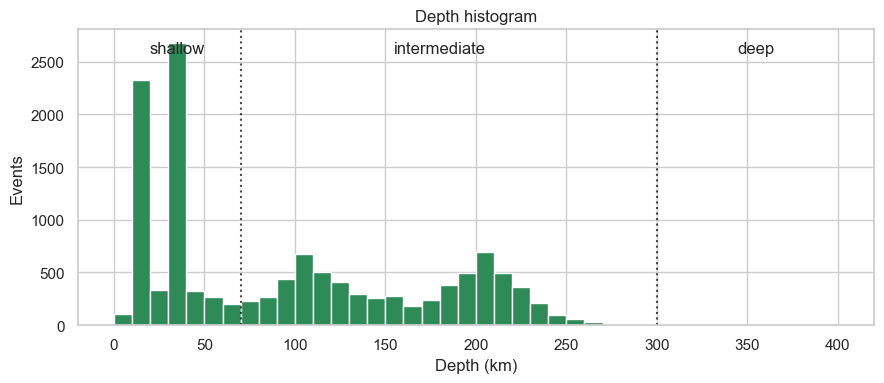

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(catalog["depth"], bins=np.arange(0, 410, 10), color="seagreen", edgecolor="white")
for boundary_km in (70, 300):
    ax.axvline(boundary_km, color="black", ls=":", alpha=0.7)
ax.set(xlabel="Depth (km)", ylabel="Events", title="Depth histogram")

ymax = ax.get_ylim()[1]
ax.text( 35, ymax * 0.92, "shallow",      ha="center")
ax.text(180, ymax * 0.92, "intermediate", ha="center")
ax.text(355, ymax * 0.92, "deep",         ha="center")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_depth_histogram.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.2 Counts per depth zone

In [12]:
depth_zone = pd.cut(
    catalog["depth"],
    bins=[-1, 70, 300, 800],
    labels=["shallow (≤70 km)", "intermediate (70–300 km)", "deep (>300 km)"],
)
zone_counts = depth_zone.value_counts().sort_index()
zone_counts

depth
shallow (≤70 km)            6225
intermediate (70–300 km)    6631
deep (>300 km)                10
Name: count, dtype: int64

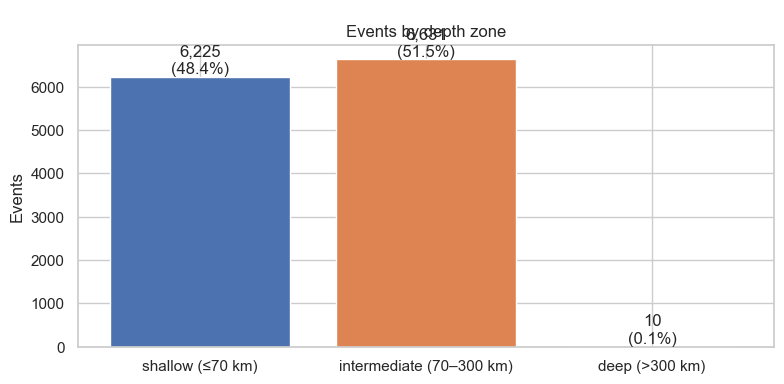

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(zone_counts.index.astype(str), zone_counts.values,
       color=["#4c72b0", "#dd8452", "#55a868"])
ax.set(ylabel="Events", title="Events by depth zone")
for i, n in enumerate(zone_counts.values):
    ax.text(i, n, f"\n{n:,}\n({100 * n / len(catalog):.1f}%)", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_depth_zones.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Geography — map of every event

Marker colour = depth (yellow shallow → purple deep), marker size grows with
magnitude. The Hindu Kush deep nest, Makran subduction, the Sulaiman/Kirthar
fold-and-thrust belt, and the Himalayan front should all be visible.

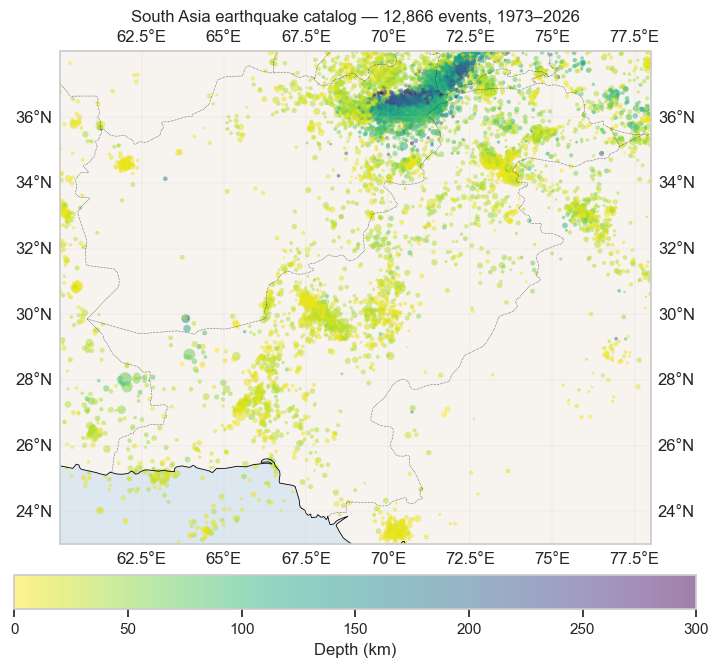

In [14]:
fig = plt.figure(figsize=(11, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([60, 78, 23, 38], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND.with_scale("50m"),      facecolor="#f7f3ee")
ax.add_feature(cfeature.OCEAN.with_scale("50m"),     facecolor="#dde7ef")
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.6)
ax.add_feature(cfeature.BORDERS.with_scale("50m"),   linewidth=0.4, linestyle=":")

marker_sizes = (catalog["mag"] - 3.0) ** 2 * 4 + 2
scatter = ax.scatter(
    catalog["longitude"], catalog["latitude"],
    c=catalog["depth"], cmap="viridis_r", vmin=0, vmax=300,
    s=marker_sizes, alpha=0.5, edgecolors="none",
    transform=ccrs.PlateCarree(),
)
plt.colorbar(scatter, ax=ax, orientation="horizontal", pad=0.05,
             label="Depth (km)", shrink=0.8)
ax.set_title(f"South Asia earthquake catalog — {len(catalog):,} events, "
             f"{first_event.year}–{last_event.year}")
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

plt.savefig(FIG_DIR / "01_map.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Time — how the catalog grows

Newer years should hold more events (better instrumentation), and big mainshock
years should pop as visible spikes from their aftershock sequences.

### 5.1 Annual event count

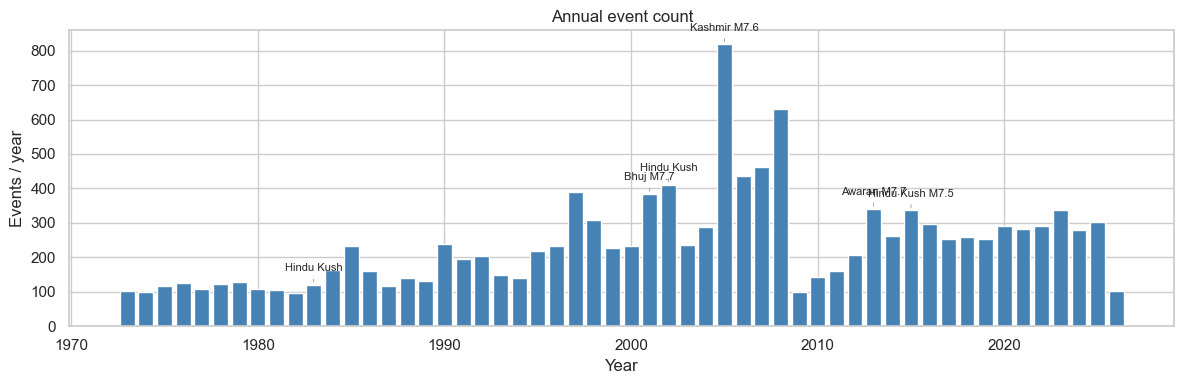

In [15]:
events_per_year = catalog["time"].dt.year.value_counts().sort_index()

famous_years = {
    1983: "Hindu Kush",
    2001: "Bhuj M7.7",
    2002: "Hindu Kush",
    2005: "Kashmir M7.6",
    2013: "Awaran M7.7",
    2015: "Hindu Kush M7.5",
}

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(events_per_year.index, events_per_year.values, color="steelblue", edgecolor="white")
ax.set(xlabel="Year", ylabel="Events / year", title="Annual event count")

for year, label in famous_years.items():
    if year in events_per_year.index:
        ax.annotate(
            label,
            xy=(year, events_per_year[year]),
            xytext=(0, 10), textcoords="offset points",
            ha="center", fontsize=8,
            arrowprops=dict(arrowstyle="-", color="grey", lw=0.5),
        )

plt.tight_layout()
plt.savefig(FIG_DIR / "01_yearly_counts.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.2 Monthly event count — aftershock spikes

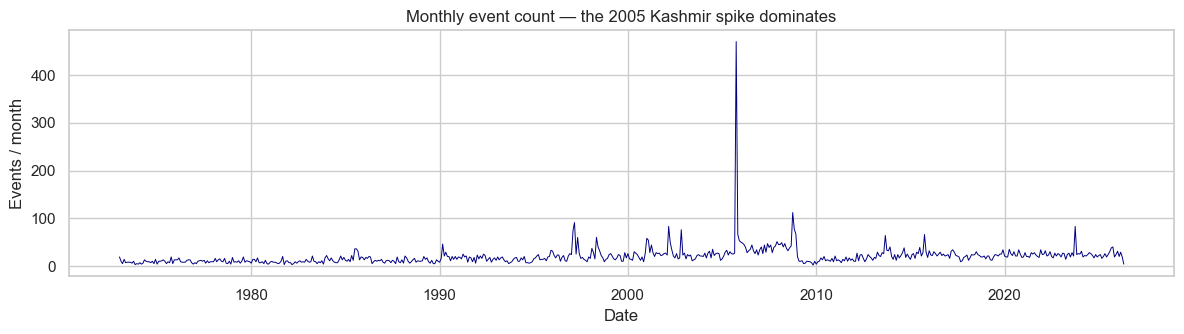

In [16]:
events_per_month = catalog["time"].dt.to_period("M").value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(events_per_month.index.to_timestamp(), events_per_month.values,
        color="navy", linewidth=0.7)
ax.set(xlabel="Date", ylabel="Events / month",
       title="Monthly event count — the 2005 Kashmir spike dominates")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_monthly_counts.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. The big ones — M ≥ 7

These mainshocks anchor the aftershock-clustering analysis later.

In [17]:
major_events = (
    catalog[catalog["mag"] >= 7.0]
    .sort_values("mag", ascending=False)
    [["time", "mag", "depth", "latitude", "longitude", "place"]]
    .reset_index(drop=True)
)
major_events["time"] = major_events["time"].dt.strftime("%Y-%m-%d")
print(f"{len(major_events)} events with M ≥ 7.0")
major_events

12 events with M ≥ 7.0


,time,mag,depth,latitude,longitude,place
0,2001-01-26,7.7,16.0,23.4190,70.2320,"17 km NW of Bhach?u, India"
1,2013-04-16,7.7,80.0,28.0330,61.9960,"79 km ESE of Kh?sh, Iran"
2,2013-09-24,7.7,15.0,26.9510,65.5009,"113 km NW of Bela, Pakistan"
3,2005-10-08,7.6,26.0,34.5390,73.5880,"21 km NNE of Muzaffar?b?d, Pakistan"
4,2015-10-26,7.5,231.0,36.5244,70.3676,"Hindu Kush region, Afghanistan"
5,1983-12-30,7.4,214.5,36.3720,70.7380,"55 km S of Jurm, Afghanistan"
6,1985-07-29,7.4,98.7,36.1900,70.8960,"75 km S of Jurm, Afghanistan"
7,2002-03-03,7.4,225.6,36.5020,70.4820,"51 km SW of Jurm, Afghanistan"
8,2011-01-18,7.2,68.0,28.7770,63.9510,"46 km WSW of Dalbandin, Pakistan"
9,1997-02-27,7.1,33.0,29.9760,68.2080,"29 km ESE of Harnai, Pakistan"


## 7. Data-quality audit

Two things to flag in the report:

1. **Missing values** in some property fields (`rms`, `gap`, `dmin`, `nst`):
   not every reporting network supplies them.
2. **Encoding artefacts** in `place` (e.g. `Kh?sh`, `Bhach?u`, `Muzaffar?b?d`):
   non-ASCII characters that USGS replaced with `?`. Cosmetic only — they do
   not affect any numeric feature.

### 7.1 Missing values per column

In [18]:
missing_counts = catalog.isna().sum().sort_values(ascending=False)
missing_pct = (100 * missing_counts / len(catalog)).round(1)
data_quality = pd.DataFrame({"missing": missing_counts, "missing %": missing_pct})
data_quality

,missing,missing %
dmin,9131,71.0
nst,7096,55.2
gap,5547,43.1
rms,942,7.3
id,0,0.0
time,0,0.0
longitude,0,0.0
latitude,0,0.0
depth,0,0.0
mag,0,0.0


### 7.2 Encoding artefacts in `place`

In [19]:
has_encoding_artefact = catalog["place"].fillna("").str.contains(r"\?", regex=True)
n_bad = int(has_encoding_artefact.sum())
print(f"Place names with `?` artefacts: {n_bad:,}  ({100 * has_encoding_artefact.mean():.1f}%)")

Place names with `?` artefacts: 5,084  (39.5%)


Most common mangled place names:

In [20]:
catalog.loc[has_encoding_artefact, "place"].value_counts().head(10)

place
41 km SW of Ashk?sham, Afghanistan    22
43 km SW of Ashk?sham, Afghanistan    21
40 km SW of Ashk?sham, Afghanistan    21
46 km SW of Ashk?sham, Afghanistan    20
44 km SW of Ashk?sham, Afghanistan    20
49 km SW of Ashk?sham, Afghanistan    20
45 km SW of Ashk?sham, Afghanistan    19
42 km SW of Ashk?sham, Afghanistan    18
48 km SW of Ashk?sham, Afghanistan    17
36 km SW of Ashk?sham, Afghanistan    17
Name: count, dtype: int64

## 8. Takeaways

- **12,866 events** over **53 years** in the South Asia plate-boundary box,
  M ≥ 3.5.
- **Mc ≈ 4.1**, **b ≈ 1.07** — within textbook expectations for tectonic
  seismicity. The catalog is reliable for ML at and above this threshold.
- **Two depth populations**: shallow (Himalayan front, Makran, Kashmir) and
  intermediate (Hindu Kush nest at ~200 km).
- **Detection rate rises** through the catalog as instrumentation improves;
  major mainshocks dominate the monthly time series (Kashmir 2005 alone
  produced ~470 events in October–November of that year).
- **Data-quality caveats**: 4 property columns have missing values for events
  reported by older networks; some non-ASCII place names are mangled.

Next: [`02_features.ipynb`](02_features.ipynb) builds per-event features
(Zaliapin η, local density, Båth and Omori residuals, etc.) on top of this
catalog.